# CSC 487 Final Project: Art Classification

NOTE: This is really just an exploratory notebook for now


TODO (for james 03.09):
- i have loaded the dataset, but need to figure out the distribution
of each type within the whole dataset (can create visualization for the paper)
- then, determine which type of thing we are going to want to use
- then, create some file that is easier for people to load and stuff

## Installations & Loading the Data

It takes forever to load this data tbh.

In [ ]:
%pip install datasets

In [ ]:
import polars as pl

In [ ]:
from datasets import load_dataset

dataset = load_dataset("huggan/wikiart")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'artist', 'genre', 'style'],
        num_rows: 81444
    })
})

## Exploratory Analysis

Try to understand distributions of artists, genres, styles.

According to the HuggingFace:

"artist" : 129 artist classes, including a "Unknown Artist" class

"genre" : 11 genre classes, including a "Unknown Genre" class

"style" : 27 style classes

We could just take a subset of the top artists, we could only take like 5 of the genres and try to classify on that, we could only take some of the styles and try to classify artist

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'artist', 'genre', 'style'],
        num_rows: 81444
    })
})

In [ ]:
from collections import Counter

ds = dataset["train"]
artist_counts = Counter()
genre_counts = Counter()
style_counts = Counter()
counted = 0

ds_no_image = ds.select_columns(["artist", "genre", "style"])

for ex in ds_no_image:                       # streams example-by-example
    artist_counts[ex["artist"]] += 1
    genre_counts[ex["genre"]] += 1
    style_counts[ex["style"]] += 1
    counted += 1
    if counted % 999 == 0:
      print(f"{counted} files analyzed ..")


print("done!")

999 files analyzed ..
1998 files analyzed ..
2997 files analyzed ..
3996 files analyzed ..
4995 files analyzed ..
5994 files analyzed ..
6993 files analyzed ..
7992 files analyzed ..
8991 files analyzed ..
9990 files analyzed ..
10989 files analyzed ..
11988 files analyzed ..
12987 files analyzed ..
13986 files analyzed ..
14985 files analyzed ..
15984 files analyzed ..
16983 files analyzed ..
17982 files analyzed ..
18981 files analyzed ..
19980 files analyzed ..
20979 files analyzed ..
21978 files analyzed ..
22977 files analyzed ..
23976 files analyzed ..
24975 files analyzed ..
25974 files analyzed ..
26973 files analyzed ..
27972 files analyzed ..
28971 files analyzed ..
29970 files analyzed ..
30969 files analyzed ..
31968 files analyzed ..
32967 files analyzed ..
33966 files analyzed ..
34965 files analyzed ..
35964 files analyzed ..
36963 files analyzed ..
37962 files analyzed ..
38961 files analyzed ..
39960 files analyzed ..
40959 files analyzed ..
41958 files analyzed ..
429

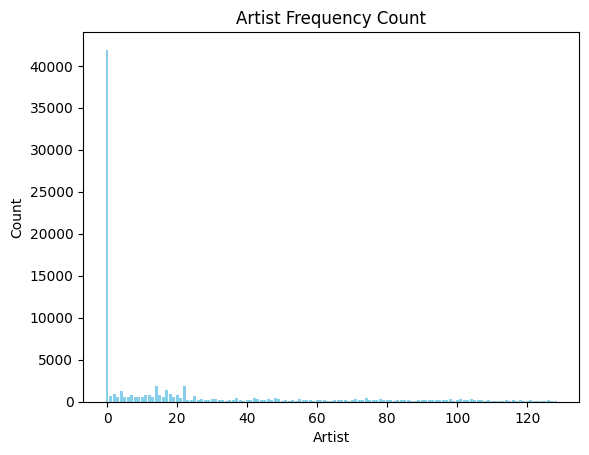

In [ ]:
# print artist distrubtion
labels = list(artist_counts.keys())
values = list(artist_counts.values())

# plt.figure(figsize=(8, 5)) # Optional: set the figure size
plt.bar(labels, values, color='skyblue')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.title('Artist Frequency Count')
plt.show()

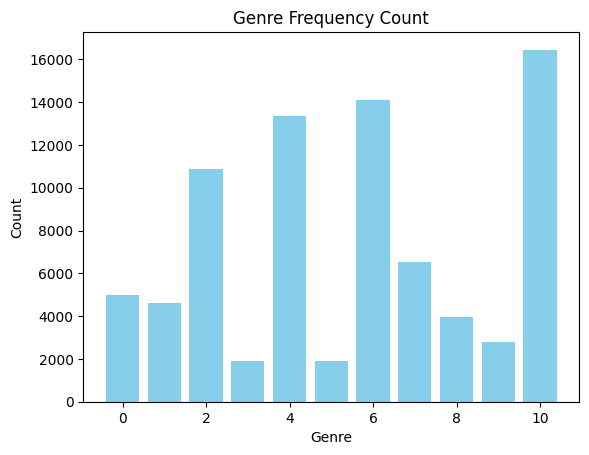

In [ ]:
labels = list(genre_counts.keys())
values = list(genre_counts.values())

# plt.figure(figsize=(8, 5)) # Optional: set the figure size
plt.bar(labels, values, color='skyblue')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Genre Frequency Count')
plt.show()

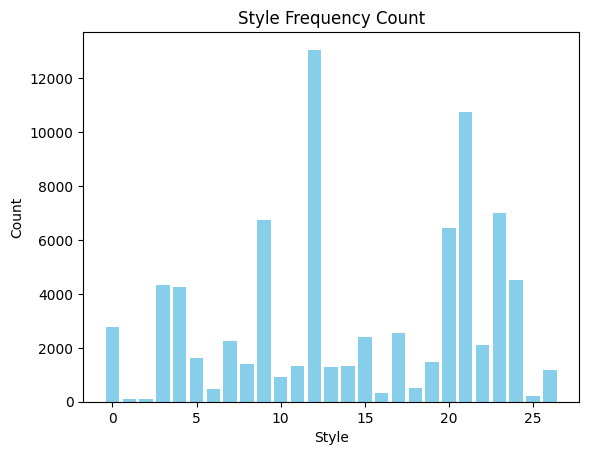

In [ ]:
labels = list(style_counts.keys())
values = list(style_counts.values())

# plt.figure(figsize=(8, 5)) # Optional: set the figure size
plt.bar(labels, values, color='skyblue')
plt.xlabel('Style')
plt.ylabel('Count')
plt.title('Style Frequency Count')
plt.show()

In [ ]:
min(artist_counts.values())

42

In [ ]:
max(artist_counts.values())

41914

In [ ]:
artist_counts.most_common(20)

[(0, 41914),
 (22, 1889),
 (14, 1819),
 (17, 1400),
 (4, 1334),
 (18, 919),
 (2, 887),
 (11, 784),
 (20, 776),
 (12, 765),
 (15, 762),
 (7, 753),
 (25, 695),
 (1, 633),
 (5, 611),
 (16, 579),
 (9, 577),
 (13, 575),
 (6, 555),
 (3, 550)]

## Create Train, Val, Test Splits

Ok, so there is a crazy imbalance in artists, but we want to reduce the total number of sample anyway. For now, I am going to take 500 random images from the top 20 artist that are represented in the dataset.


NOTE that we are stratifying by artist (for the top 20, that is)!


80/10/10 train/val/test split, so:
- 8K train
- 1K validation
- 1K test

In [ ]:
# find the top 20 artists

import numpy as np

seed = 42
rng = np.random.default_rng(seed)

top20 = Counter(ds_no_image["artist"]).most_common(20)
top20_artists = []

for artist, count in top20:
  top20_artists.append(artist)

top20_artists

[0, 22, 14, 17, 4, 18, 2, 11, 20, 12, 15, 7, 25, 1, 5, 16, 9, 13, 6, 3]

In [ ]:
# create dictionary
# key: artist
# value: list of indices

from collections import defaultdict

idx_by_artist = defaultdict(list)

for index, artist in enumerate(ds_no_image["artist"]):
    if artist in top20_artists:
        idx_by_artist[artist].append(index)

20

In [ ]:
# sample randomly from dictionary

n_per_artist = 500
sampled_indices = []

for a in top20_artists:
    sampled = rng.choice(idx_by_artist[a], size=n_per_artist, replace=False)
    sampled_indices.extend(sampled.tolist())

In [ ]:
# now, build the balanced dataset

balanced_ds = ds.select(sampled_indices).shuffle(seed=seed)

balanced_ds

In [ ]:
# then, split this balanced data into train, val, and test splits

first_splits = balanced_ds.train_test_split(test_size=0.2, seed=seed, stratify_by_column="artist")

train_ds = first_splits["train"]
temp = first_splits["test"]

test_splits = temp.train_test_split(test_size=0.5, seed=seed, stratify_by_column="artist")
val_ds = test_splits["train"]
test_ds = test_splits["test"]


In [ ]:
# finally: export to parquet
train_ds.to_parquet("train.parquet")
val_ds.to_parquet("val.parquet")
test_ds.to_parquet("test.parquet")

Creating parquet from Arrow format:   0%|          | 0/80 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

467532821

In [ ]:
# NOTE: you can load the parquet files like this:
# from datasets import load_dataset
# ds = load_dataset("parquet", data_files={"train": "train.parquet"})